<a href="https://colab.research.google.com/github/ananthakrishnanm010/Emotion_NLP_Project/blob/main/NLP_Parallel_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install gensim

# Libraries

In [74]:
import pandas as pd
import numpy as np
import string
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.stem import  WordNetLemmatizer
nltk.download('wordnet')

import gensim
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Read Dataset

In [38]:
df_emotion = pd.read_parquet("hf://datasets/dair-ai/emotion/unsplit/train-00000-of-00001.parquet")


df_emotion.head(3)

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1


# EDA

In [39]:
df_emotion.head()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [40]:
df_emotion.shape

(416809, 2)

In [41]:
df_emotion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


In [42]:
df_emotion.isnull().sum()

,0
text,0
label,0


In [43]:
df_emotion['label'].value_counts()

,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


In [44]:
# inference
# The target column is 'label'
# Based on the text in the 'text' column we have to identify the emotion in label
# label:  sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5).

In [45]:
df_emotion = df_emotion[['label','text']]  # to display lablel first and text later for convinience

# Preprocessing

## Duplicate removal

In [46]:
df_emotion.duplicated().sum()

np.int64(686)

In [47]:
df_emotion = df_emotion.drop_duplicates()

In [48]:
df_emotion.duplicated().sum()

np.int64(0)

## Punctuation Removal

In [49]:
def remove_punc(text):
  text = str(text)
  text = text.replace("�", "")
  punctuationless_text = ''.join(i for i in text if i not in string.punctuation)
  return punctuationless_text

In [50]:
df_emotion["punctuationless_text"] = [remove_punc(text) for text in df_emotion["text"]]

In [51]:
df_emotion.head()

,label,text,punctuationless_text
0,0,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...
1,0,im alone i feel awful,im alone i feel awful
2,1,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...
3,0,i was feeling a little low few days back,i was feeling a little low few days back
4,2,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...


## Lowercasing

In [52]:
df_emotion["lowercased"] = [text.lower() for text in df_emotion["punctuationless_text"]]

In [53]:
df_emotion.head()

,label,text,punctuationless_text,lowercased
0,0,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...
1,0,im alone i feel awful,im alone i feel awful,im alone i feel awful
2,1,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...
3,0,i was feeling a little low few days back,i was feeling a little low few days back,i was feeling a little low few days back
4,2,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...


## Tokenization

In [54]:
# we convert the entire text into a list of unique words.
def tokenization(text):
  word_list = nltk.word_tokenize(text)
  return word_list

In [55]:
df_emotion["tokenized"] = [tokenization(text) for text in df_emotion["lowercased"]]

In [56]:
df_emotion.head()

,label,text,punctuationless_text,lowercased,tokenized
0,0,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,"[i, feel, awful, about, it, too, because, it, ..."
1,0,im alone i feel awful,im alone i feel awful,im alone i feel awful,"[im, alone, i, feel, awful]"
2,1,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,"[ive, probably, mentioned, this, before, but, ..."
3,0,i was feeling a little low few days back,i was feeling a little low few days back,i was feeling a little low few days back,"[i, was, feeling, a, little, low, few, days, b..."
4,2,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,"[i, beleive, that, i, am, much, more, sensitiv..."


## Stop Words Removal

In [57]:
stop_words_list = nltk.corpus.stopwords.words('english')
stop_words_list
def remove_stopwords(tokens):
  stop_word_less_list = [i for i in tokens if i not in stop_words_list]
  return stop_word_less_list

In [58]:
df_emotion["stop_words_removed"] = [remove_stopwords(text) for text in df_emotion["tokenized"]]

In [59]:
df_emotion.head()

,label,text,punctuationless_text,lowercased,tokenized,stop_words_removed
0,0,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,"[i, feel, awful, about, it, too, because, it, ...","[feel, awful, job, get, position, succeed, hap..."
1,0,im alone i feel awful,im alone i feel awful,im alone i feel awful,"[im, alone, i, feel, awful]","[im, alone, feel, awful]"
2,1,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,"[ive, probably, mentioned, this, before, but, ...","[ive, probably, mentioned, really, feel, proud..."
3,0,i was feeling a little low few days back,i was feeling a little low few days back,i was feeling a little low few days back,"[i, was, feeling, a, little, low, few, days, b...","[feeling, little, low, days, back]"
4,2,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,"[i, beleive, that, i, am, much, more, sensitiv...","[beleive, much, sensitive, peoples, feelings, ..."


## Lemmatization

In [60]:
lem_obj = WordNetLemmatizer()
def lemmatizing(stem_token_list):
  lem_list = [lem_obj.lemmatize(word) for word in stem_token_list ]
  return lem_list


In [61]:
df_emotion["lemmatized_text"] = [lemmatizing(text) for text in df_emotion["stop_words_removed"]]

In [62]:
df_emotion.head()

,label,text,punctuationless_text,lowercased,tokenized,stop_words_removed,lemmatized_text
0,0,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,"[i, feel, awful, about, it, too, because, it, ...","[feel, awful, job, get, position, succeed, hap...","[feel, awful, job, get, position, succeed, hap..."
1,0,im alone i feel awful,im alone i feel awful,im alone i feel awful,"[im, alone, i, feel, awful]","[im, alone, feel, awful]","[im, alone, feel, awful]"
2,1,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,"[ive, probably, mentioned, this, before, but, ...","[ive, probably, mentioned, really, feel, proud...","[ive, probably, mentioned, really, feel, proud..."
3,0,i was feeling a little low few days back,i was feeling a little low few days back,i was feeling a little low few days back,"[i, was, feeling, a, little, low, few, days, b...","[feeling, little, low, days, back]","[feeling, little, low, day, back]"
4,2,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,"[i, beleive, that, i, am, much, more, sensitiv...","[beleive, much, sensitive, peoples, feelings, ...","[beleive, much, sensitive, people, feeling, te..."


# Embedding

## TF-IDF  

In [63]:
df_emotion['text'] = df_emotion['lemmatized_text'].apply(lambda x: ' '.join(x))

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df_emotion['text'])

y = df_emotion['label']

print("Shape of TF-IDF Matrix:", X.shape)


Shape of TF-IDF Matrix: (416123, 5000)


## splitting the dataset

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (332898, 5000)
Testing Data Shape  : (83225, 5000)


# Model

## Deep Learning Model(ANN)

In [65]:
model = Sequential([

    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
# compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [67]:
# train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 334s 40ms/step - accuracy: 0.8643 - loss: 0.3432 - val_accuracy: 0.8991 - val_loss: 0.2179
Epoch 2/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 313s 38ms/step - accuracy: 0.8990 - loss: 0.2180 - val_accuracy: 0.9036 - val_loss: 0.1898
Epoch 3/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 313s 38ms/step - accuracy: 0.9090 - loss: 0.1847 - val_accuracy: 0.9052 - val_loss: 0.1877
Epoch 4/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 318s 38ms/step - accuracy: 0.9176 - loss: 0.1622 - val_accuracy: 0.9045 - val_loss: 0.1890
Epoch 5/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 322s 38ms/step - accuracy: 0.9231 - loss: 0.1471 - val_accuracy: 0.9052 - val_loss: 0.1941
Epoch 6/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 314s 38ms/step - accuracy: 0.9273 - loss: 0.1348 - val_accuracy: 0.9033 - val_loss: 0.2130
Epoch 7/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 313s 38ms/step - accuracy: 0.9311 - loss: 0.1256 - val_accuracy: 0.9034 - val_loss: 0.2274
Epoch 8/10
8323/8323 ━━━━━━━━━━━━━━━━━━━━ 325s 38ms/step - accuracy: 

In [68]:
# evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2601/2601 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9007 - loss: 0.2691
Test Loss: 0.2691
Test Accuracy: 0.9007


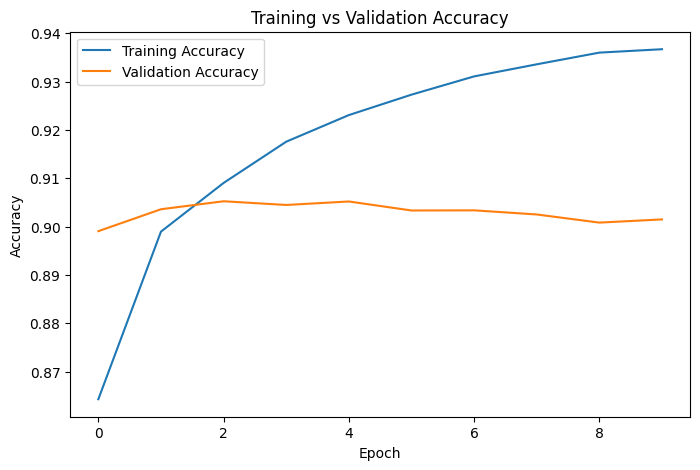

In [69]:
# plotting Training & Validation Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

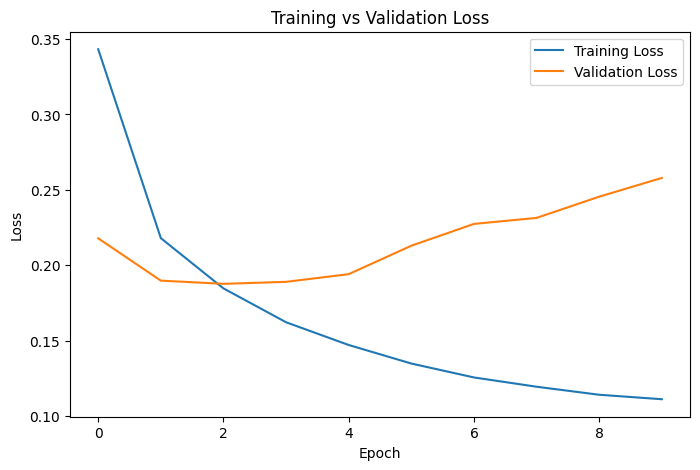

In [70]:
# Plotting Training vs Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [71]:
# Prediction based on test data
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

2601/2601 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step


In [73]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     24198
           1       0.91      0.95      0.93     28156
           2       0.90      0.68      0.78      6899
           3       0.90      0.90      0.90     11447
           4       0.83      0.89      0.85      9533
           5       0.81      0.67      0.74      2992

    accuracy                           0.90     83225
   macro avg       0.88      0.84      0.86     83225
weighted avg       0.90      0.90      0.90     83225



In [ ]:
# INFERENCE
# -----------------------------
# Accuracy is 90% - that means excellent performance in emotion classification
# Classes 0, 1, and 3 obtained F1-scores above 0.90, demonstrating highly accurate predictions.
# Classes 2 and 5 showed comparatively lower recall values (0.68 and 0.67),
                   #indicating that the model missed a noticeable number of instances
# the weighted F1-score of 0.90 suggests that the model
      #  performs consistently well across the dataset and generalizes effectively.

### Confusion matrix

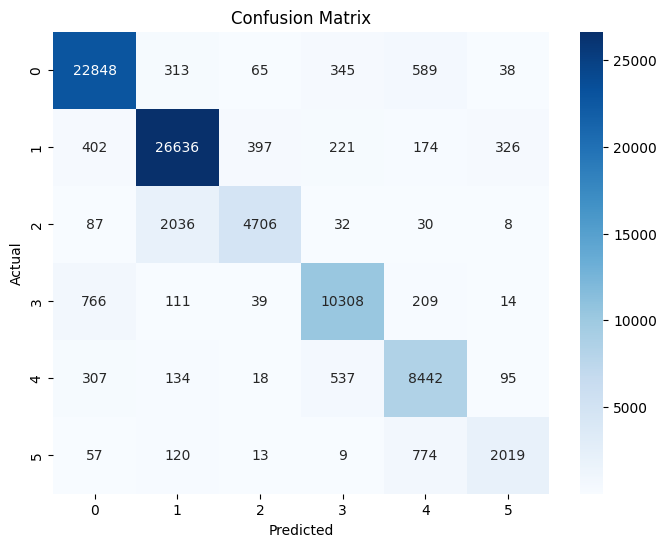

In [75]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [76]:
# saving the model
model.save("emotion_classifier_tfidf.keras")